# Scottish Election May 2026 polls analysis

## Data Ingestion and software prerequisites

In [1]:
import pandas as pd

Raw data from https://knutley.github.io/STAEM_Project/

In [2]:
constituency_df=pd.read_csv('constituency.csv',parse_dates=[0],sep='\%?,',engine='python')

In [3]:
regional_df=pd.read_csv('regional_list.csv',parse_dates=[0],sep='\%?,',engine='python')

## Analysis

### Constituency

<AxesSubplot: xlabel='Date', ylabel='Sample size'>

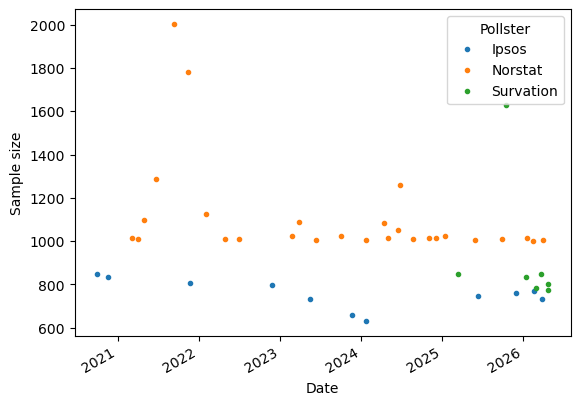

In [4]:
(constituency_df
 .set_index(['Date','Pollster'])
 .unstack()
 .Sample
 #.SNP
 .plot(marker='.',ls='',ylabel='Sample size')#,colors={'Con':'tab10-blue'})
)

<AxesSubplot: xlabel='Date'>

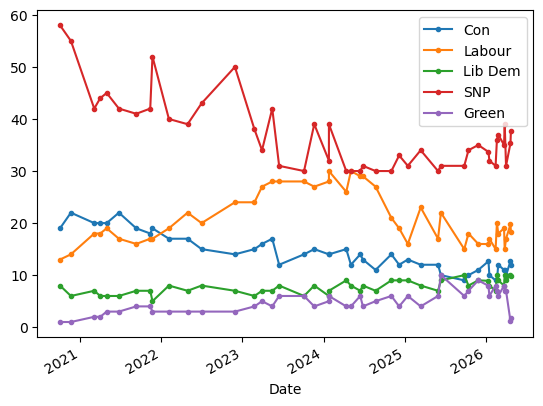

In [5]:
(constituency_df
 .set_index('Date')
 .drop(columns='Sample')
 #.SNP
 .plot(marker='.')#,colors={'Con':'tab10-blue'})
)

Gives the impression that SNP is oscillating up and down

<AxesSubplot: xlabel='Date'>

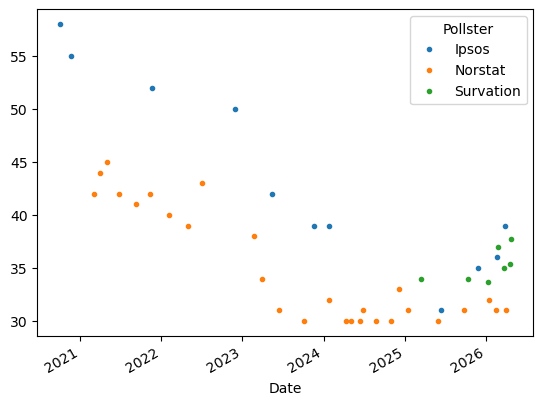

In [6]:
constituency_df[['Date','Pollster','SNP']].pivot(index='Date',columns='Pollster',values='SNP').plot(marker='.',ls='')

Ipsos with smaller sample sizes consistently shows SNP high. Norstat with higher sample sizes shows it low in the earlier years of the decade.

<AxesSubplot: xlabel='Date'>

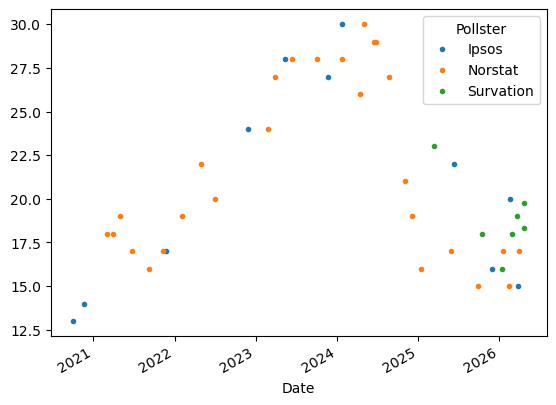

In [7]:
(constituency_df
 [['Date','Pollster','Labour']]
 .pivot(index='Date',columns='Pollster',values='Labour')
 .plot(marker='.',ls='')
)

likewise Labour oscillates between low Norstat and high other in the last couple of years

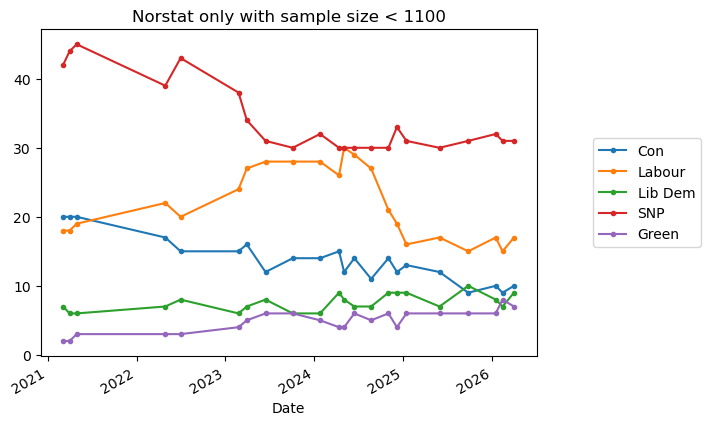

In [8]:
(constituency_df
 .query('Pollster=="Norstat" and Sample<1100')
 .set_index('Date')
 .drop(columns='Sample')
 #.SNP
 .plot(marker='.',title="Norstat only with sample size < 1100")#,colors={'Con':'tab10-blue'})
 .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
)

### regional

<AxesSubplot: xlabel='Date'>

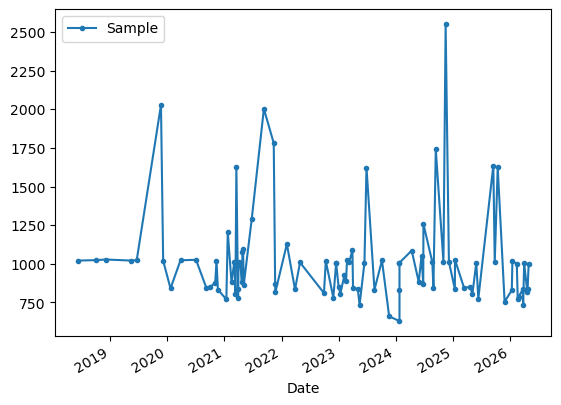

In [11]:
(regional_df
 .set_index(['Date'])#,'Pollster'])
 .sort_index()
 #.unstack()
 #.drop(columns='Sample')
 #.SNP
 .loc['2016':]
 .plot(marker='.')#,colors={'Con':'tab10-blue'})
)

In [10]:
regional_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      95 non-null     datetime64[ns]
 1   Pollster  95 non-null     object        
 2   Client    95 non-null     object        
 3   Sample    95 non-null     int64         
 4   Con       95 non-null     object        
 5   Labour    95 non-null     object        
 6   Lib Dem   95 non-null     object        
 7   SNP       95 non-null     object        
 8   Alba      95 non-null     object        
 9   Reform    95 non-null     object        
 10  Green     95 non-null     object        
 11  Others    95 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 9.0+ KB
